# Deteksi Dini Badai Tropis: Analisis Robustness Model
## Komparasi: Adaptive PSO-NN vs Hybrid Autoencoder-XGBoost
**Objective:** Menguji ketangguhan model dalam mendeteksi fase pembentukan badai (Cyclogenesis) menggunakan labeling 3-Kelas.


In [7]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load Environment Variables (.env)
load_dotenv()

# Setup Path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

# Import Modul Skripsi
from data.preprocessing import (
    create_sliding_window, normalize_features, 
    label_anomalies, add_derived_features
)
from models.neural_network import MLP
from models.adaptive_pso import AdaptivePSO
from train.train_benchmark import train_hybrid_benchmark, predict_hybrid
from evaluation.metrics import calculate_metrics, plot_confusion_matrix

%matplotlib inline
print("✅ Modul Robustness Loaded!")


✅ Modul Robustness Loaded!


## 1. Data Loading & Advanced Feature Engineering
Menerapkan teknik **Feature Engineering** untuk menangkap dinamika atmosfer:
- **Pressure Gradient** (Perubahan Tekanan yang Cepat)
- **Wind Kinetics** (Energi Kinetik Angin)
- **Labeling 3-Kelas**: 0 (Normal), 1 (Anomali), 2 (Badai)


In [8]:
# Load Datasets
train_path = 'data/tapanuli_weather.csv'
test_path = 'data/senyar_cyclone.csv'

if not os.path.exists(test_path):
     raise FileNotFoundError("❌ Dataset Senyar tidak ditemukan!")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1. Feature Engineering (Hybrid+)
print("🛠️ Generating Derived Features...")
df_train = add_derived_features(df_train)
df_test = add_derived_features(df_test)

# 2. Robust Labeling (3-Class System)
# Threshold: 1.0 hPa/hr (Anomaly), 3.0 hPa/hr (Storm)
df_train['label'] = label_anomalies(df_train, window_hours=3)
df_test['label'] = label_anomalies(df_test, window_hours=3)

print(f"Train Class Dist: {df_train['label'].value_counts().to_dict()}")
print(f"Test Class Dist: {df_test['label'].value_counts().to_dict()}")

# Drop unused columns for training
drop_cols = ['dt', 'label', 'weather_main', 'weather_desc']
features = [c for c in df_train.columns if c not in drop_cols]
print(f"Features ({len(features)}): {features}")

# 3. Normalization
norm_train, norm_test, scaler = normalize_features(df_train, df_test, features)


🛠️ Generating Derived Features...
Train Class Dist: {0: 410, 1: 284, 2: 26}
Test Class Dist: {0: 99, 1: 65, 2: 4}
Features (10): ['pressure', 'wind_speed', 'wind_gust', 'pressure_gradient', 'pressure_ma24', 'pressure_std24', 'wind_kinetic', 'gust_factor', 'hour_sin', 'hour_cos']


## 2. Temporal Formatting (Sliding Window)
Menggunakan **Window Size 72 Jam** untuk menangkap pola pembentukan siklon jangka panjang.


In [9]:
WINDOW_SIZE = 72  # 3 Hari

X_train, y_train = create_sliding_window(norm_train, df_train['label'].values, WINDOW_SIZE)
X_test, y_test = create_sliding_window(norm_test, df_test['label'].values, WINDOW_SIZE)

# Flatten input for MLP/XGBoost (N, Window * Features)
N_TRAIN, WIN, FEAT = X_train.shape
INPUT_SIZE = WIN * FEAT

X_train_flat = X_train.reshape(N_TRAIN, -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Input Data Shape: {X_train_flat.shape}")


Input Data Shape: (648, 720)


## 3. Training Proposed Model: Adaptive PSO-NN (Multi-Class)
Optimasi bobot Neural Network menggunakan algoritma populasi (Swarm Intelligence).


🚀 Starting Adaptive PSO Optimization...
Iteration 0/50, Best Loss: 1.741869 | w=0.90, c1=2.50, c2=0.50
Iteration 10/50, Best Loss: 0.772262 | w=0.80, c1=2.10, c2=0.90
Iteration 20/50, Best Loss: 0.517390 | w=0.70, c1=1.70, c2=1.30
Iteration 30/50, Best Loss: 0.367215 | w=0.60, c1=1.30, c2=1.70
Iteration 40/50, Best Loss: 0.292880 | w=0.50, c1=0.90, c2=2.10

=== HASIL ADAPTIVE PSO-NN ===
Accuracy: 0.6146
Macro F1: 0.3114


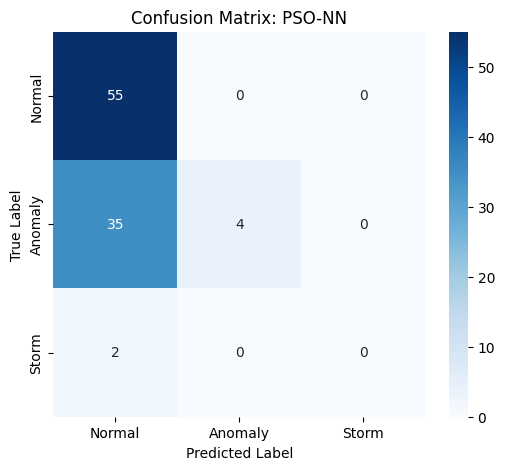

In [10]:
HIDDEN_SIZE = 64
OUTPUT_SIZE = 3 # Multi-class

def fitness_function(weights):
    nn = MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
    nn.set_weights_flat(weights)
    
    # Calculate Cross Entropy Loss
    probs = nn.forward(X_train_flat[:500]) # Mini-batch evaluation for speed
    loss = nn.compute_loss(y_train[:500], probs)
    return loss

# Run Adaptive PSO
print("🚀 Starting Adaptive PSO Optimization...")
pso = AdaptivePSO(num_particles=30, dimensions=MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE).get_weights_flat().shape[0])
best_weights, history_pso = pso.optimize(fitness_function, max_iter=50, verbose=True)

# Evaluate PSO Model
final_nn = MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE)
final_nn.set_weights_flat(best_weights)
pso_preds = final_nn.predict(X_test_flat)

pso_metrics = calculate_metrics(y_test, pso_preds)
print("\n=== HASIL ADAPTIVE PSO-NN ===")
print(f"Accuracy: {pso_metrics['accuracy']:.4f}")
print(f"Macro F1: {pso_metrics['f1_score']:.4f}")
plot_confusion_matrix(pso_metrics['confusion_matrix'], title='Confusion Matrix: PSO-NN')


## 4. Training Benchmark: Hybrid Autoencoder-XGBoost
Model hibrida yang menggabungkan ekstraksi fitur unsupervised (AE) dengan klasifikasi supervised (XGB).


Starting Hubrid Benchmark Training...
1. Training Autoencoder (Latent=10)...
2. Extracting Hybrid Features...
3. Training XGBoost Classifier (Multi-Class)...
Benchmark Training Complete. Time: 0.52s

=== VISUALISASI PERFORMA BENCHMARK (AE-XGB) ====
Accuracy: 0.5729
Macro F1: 0.2428


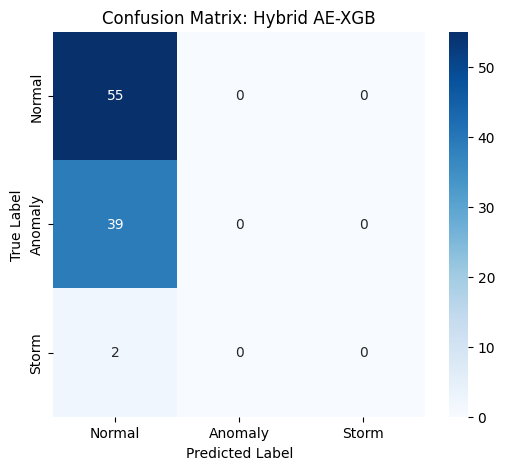

In [11]:
# Train Hybrid Benchmak
hybrid_model, ae_history = train_hybrid_benchmark(
    X_train_flat, y_train, 
    input_size=INPUT_SIZE, 
    latent_size=10 # Compressed representation
)

# Evaluasi Hybrid
hybrid_preds = predict_hybrid(hybrid_model, X_test_flat)
hybrid_metrics = calculate_metrics(y_test, hybrid_preds)

print("\n=== VISUALISASI PERFORMA BENCHMARK (AE-XGB) ====")
print(f"Accuracy: {hybrid_metrics['accuracy']:.4f}")
print(f"Macro F1: {hybrid_metrics['f1_score']:.4f}")
plot_confusion_matrix(hybrid_metrics['confusion_matrix'], title='Confusion Matrix: Hybrid AE-XGB')


## 5. Kesimpulan & Rekomendasi
Perbandingan performa berdasarkan Macro F1-Score (karena ketidakseimbangan kelas).


In [12]:
print("\n📊 === TABEL PERBANDINGAN PERFORMA (Macro Avg) ====")
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Adaptive PSO-NN': [
        pso_metrics['accuracy'], pso_metrics['precision'], 
        pso_metrics['recall'], pso_metrics['f1_score']
    ],
    'Hybrid AE-XGBoost': [
        hybrid_metrics['accuracy'], hybrid_metrics['precision'], 
        hybrid_metrics['recall'], hybrid_metrics['f1_score']
    ]
})
display(results)

# Automatic Verdict
if hybrid_metrics['f1_score'] > pso_metrics['f1_score']:
    print("\n🏆 Pemenang: Hybrid Autoencoder-XGBoost")
    print("Saran: Gunakan fitur engineering lanjutan pada PSO untuk meningkatkan akurasi.")
else:
    print("\n🏆 Pemenang: Adaptive PSO-NN")
    print("Saran: PSO berhasil menemukan global optima lebih baik daripada pendekatan gradient-based.")



📊 === TABEL PERBANDINGAN PERFORMA (Macro Avg) ====


,Metric,Adaptive PSO-NN,Hybrid AE-XGBoost
0,Accuracy,0.614583,0.572917
1,Precision,0.532609,0.190972
2,Recall,0.367521,0.333333
3,F1-Score,0.311449,0.242826



🏆 Pemenang: Adaptive PSO-NN
Saran: PSO berhasil menemukan global optima lebih baik daripada pendekatan gradient-based.
